# 🧠 Modelado Predictivo del Trade-off Cómputo–Memoria
## Entrenamiento, Calibración y Validación de Modelos Predictivos

**Proyecto:** Modelado y Optimización del Trade-off Cómputo–Memoria mediante Estrategias de Rematerialización en Entrenamiento de Redes Neuronales

**Autores:** Santiago González Flores (2200165) · Andrey Felipe Leguizamo Cespedes (2201998)

**Director:** M. Eng. Luis Alejandro Torres Niño

**Universidad Industrial de Santander – Escuela de Ingeniería de Sistemas e Informática**

---

Este notebook implementa las secciones **5.2** y **5.3** de la metodología:

1. **Sección 5.2 – Entrenamiento del modelo predictivo:** Preprocesamiento, normalización, cross-validation y entrenamiento de un modelo SGDRegressor (Regresión Lineal Múltiple) y un Random Forest, ambos multi-output para predecir simultáneamente los dos targets.
2. **Sección 5.3 – Calibración y validación:** Métricas MAE, RMSE, R²; análisis de convergencia; pruebas estadísticas (Levene, ANOVA, Tukey HSD, Kruskal-Wallis).

**Variables objetivo (targets):**
- `memory_avg_MB`: Memoria promedio consumida (indicador de **memoria**).
- `total_time_ms`: Tiempo total de profiling por iteración (indicador de **cómputo**).


---
## 1. Configuración del Entorno

In [1]:
!pip install scikit-learn-intelex -q

from sklearnex import patch_sklearn
patch_sklearn()
print('✅ scikit-learn-intelex activado')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 MB 8.3 MB/s eta 0:00:00
✅ scikit-learn-intelex activado


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from scipy.stats import levene, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12,
                      'axes.titlesize': 14, 'axes.labelsize': 12})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Librerías importadas')

✅ Librerías importadas


---
## 2. Carga y Exploración del Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# En Google Colab: subir el archivo o montarlo desde Drive
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/drive/MyDrive/tesis/Resultados_MLP_CNN.csv')
print(f'Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Valores nulos: {df.isnull().sum().sum()}')
df.head(3)

Dataset: 1894 filas × 86 columnas
Valores nulos: 0


,model_MLP-3,model_MLP-5,model_MLP-7,model_LeNet-5,model_AlexNet,model_VGG-16,activation_leaky_relu,activation_relu,activation_sigmoid,activation_tanh,...,ahorro_memoria_pct,tiempo_extra_ms,gpu_memory_gb,cuda_cores,render_cores,best_epoch,train_acc,val_acc,total_train_time_s,batch_size
0,1.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,...,0.0,0.0,64.0,0.0,6656.0,10,0.99965,0.9851,74.751,16
1,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,...,0.0,0.0,64.0,0.0,6656.0,10,0.99797,0.9857,75.374,16
2,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,...,0.0,0.0,64.0,0.0,6656.0,10,0.99887,0.9824,78.563,16


In [5]:
# ================================================================
# TARGETS: las dos dimensiones del trade-off
# ================================================================
TARGET_COLS = ['memory_avg_MB', 'total_time_ms']

# ================================================================
# COLUMNAS EXCLUIDAS (evitar data leakage y redundancia)
# ================================================================
EXCLUDE_COLS = [
    # Targets
    'memory_avg_MB', 'total_time_ms',
    # Leakage: derivadas de la misma medición de profiling
    'peak_memory_MB',       # corr 0.95 con memory_avg_MB
    'time_per_iter_ms',     # corr 1.00 con total_time_ms
    'throughput',           # inverso del tiempo
    'ahorro_memoria_pct',   # derivado de memoria
    'tiempo_extra_ms',      # derivado del tiempo
    #'total_flops',          # métrica derivada del cómputo
    'factor_recompute',     # factor analítico derivado de la estrategia
    # Resultados de entrenamiento (no son configuración elegible)
    'best_epoch', 'train_acc', 'val_acc', 'total_train_time_s',
    # Specs hardware (redundantes con one-hot de GPU)
    'gpu_memory_gb', 'cuda_cores', 'render_cores',
]

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'Features: {len(FEATURE_COLS)} columnas')
print(f'Targets:  {len(TARGET_COLS)} columnas')
print(f'Excluidas: {len(EXCLUDE_COLS)} columnas')
print(f'\nFeatures: {FEATURE_COLS}')


Features: 71 columnas
Targets:  2 columnas
Excluidas: 15 columnas

Features: ['model_MLP-3', 'model_MLP-5', 'model_MLP-7', 'model_LeNet-5', 'model_AlexNet', 'model_VGG-16', 'activation_leaky_relu', 'activation_relu', 'activation_sigmoid', 'activation_tanh', 'mode_normal', 'capa_checkpoint_fc2', 'capa_checkpoint_fc2_fc4', 'capa_checkpoint_fc3', 'capa_checkpoint_fc4', 'capa_checkpoint_fc2_fc4_fc6', 'capa_checkpoint_fc2_fc5', 'capa_checkpoint_fc2_fc6', 'capa_checkpoint_fc3_fc5', 'capa_checkpoint_fc3_fc6', 'capa_checkpoint_fc4_fc6', 'capa_checkpoint_fc5', 'capa_checkpoint_fc6', 'capa_checkpoint_block1', 'capa_checkpoint_block1_block2', 'capa_checkpoint_block1_block2_block3', 'capa_checkpoint_block1_block2_block3_block4', 'capa_checkpoint_block1_block2_block3_block4_block5', 'capa_checkpoint_block1_fc_block', 'capa_checkpoint_block2', 'capa_checkpoint_block2_fc_block', 'capa_checkpoint_block3', 'capa_checkpoint_block3_fc_block', 'capa_checkpoint_block4', 'capa_checkpoint_block4_fc_block', '

---
## 3. Preprocesamiento de Datos

Según la sección 5.2 de la metodología:
1. **Sin eliminación de outliers:** Datos experimentales reales de GUANE.
2. **División 70/15/15:** Entrenamiento (70%), validación (15%) y prueba (15%), con **shuffle** previo.
3. **Cross-validation (5-Fold):** Aplicado dentro del 70% de train para evaluar estabilidad.
4. **Normalización:** Integrada en el Pipeline del SGD.

In [6]:
X = df[FEATURE_COLS].values
y = df[TARGET_COLS].values  # shape: (n, 2) → multi-output

# ================================================================
# División 70% train / 15% validación / 15% test
# ================================================================
# shuffle=True es NECESARIO porque el dataset está ordenado:
# primero todos los MLP (filas 1-640), luego todas las CNN (641-1894).
# Sin shuffle, el test quedaría solo con VGG-16 y el modelo nunca
# habría visto esa arquitectura durante entrenamiento.
# ================================================================

# Primera división: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True
)

# Segunda división: 50/50 del 30% → 15% validación + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, shuffle=True
)

print(f'Total de datos: {len(df)} (sin eliminar outliers)')
print(f'Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Validación:    {X_val.shape[0]} muestras ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(df)*100:.1f}%)')

# KFold para cross-validation (se aplica SOLO sobre train)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'\nCross-validation: 5-Fold (sobre el 70% de train)')

Total de datos: 1894 (sin eliminar outliers)
Entrenamiento: 1325 muestras (70.0%)
Validación:    284 muestras (15.0%)
Prueba:        285 muestras (15.0%)

Cross-validation: 5-Fold (sobre el 70% de train)


---
## 4. SGD Regressor (Regresión Lineal Múltiple) — Multi-Output con Pipeline

Se usa `Pipeline` + `MultiOutputRegressor` + `SGDRegressor`:

- **Pipeline:** Encapsula `StandardScaler` + modelo. El scaler se ajusta **solo en el train de cada fold** de CV, evitando leakage en la normalización.
- **MultiOutputRegressor:** Envuelve el SGD para predecir ambos targets (`memory_avg_MB` y `total_time_ms`) como un **único modelo**.
- **`early_stopping=True`:** El modelo para automáticamente cuando la validación interna deja de mejorar, sin necesidad de barrer iteraciones manualmente.
- **Regularización ElasticNet** (`alpha=0.001`, `l1_ratio=0.15`): combina L1 (sparsity) y L2 (estabilidad).

In [7]:
# Definir el pipeline SGD multi-output
sgd_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MultiOutputRegressor(
        SGDRegressor(
            loss='squared_error',
            penalty='elasticnet',
            alpha=0.001,
            l1_ratio=0.15,
            learning_rate='adaptive',
            eta0=0.01,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=10,
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    ))
])

print('Pipeline SGD definido:')
print(sgd_pipeline)

Pipeline SGD definido:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=SGDRegressor(alpha=0.001,
                                                             early_stopping=True,
                                                             learning_rate='adaptive',
                                                             max_iter=3000,
                                                             n_iter_no_change=10,
                                                             penalty='elasticnet',
                                                             random_state=42,
                                                             validation_fraction=0.15)))])


### ¿Por qué Cross-Validation?

La **validación cruzada (5-Fold CV)** se aplica **dentro del 70% de entrenamiento** para evaluar la estabilidad del modelo. Divide el train en 5 partes iguales, rota cuál es validación, y reporta R² medio ± std.

**Esquema del split (sección 5.2 de la metodología):**
```
Dataset completo (1,894 filas) — shuffle antes de dividir
│
├── 70% Train (1,325 filas) ← Cross-validation se aplica AQUÍ
│       ├── Fold 1: [Val_cv] [Train_cv] [Train_cv] [Train_cv] [Train_cv]
│       ├── Fold 2: [Train_cv] [Val_cv] [Train_cv] [Train_cv] [Train_cv]
│       ├── Fold 3: [Train_cv] [Train_cv] [Val_cv] [Train_cv] [Train_cv]
│       ├── Fold 4: [Train_cv] [Train_cv] [Train_cv] [Val_cv] [Train_cv]
│       └── Fold 5: [Train_cv] [Train_cv] [Train_cv] [Train_cv] [Val_cv]
│       → R² medio ± std (indica estabilidad del modelo)
│
├── 15% Validación (284 filas) ← curvas de convergencia
│       (R² vs iteraciones SGD, R² vs árboles RF)
│
└── 15% Test (285 filas) ← evaluación final, nunca visto
        (MAE, RMSE, R² reportados en resultados)
```

**¿Por qué shuffle?** El dataset está ordenado por modelo (primero MLP, luego CNN). Sin mezclar, el test quedaría solo con las últimas filas (VGG-16) y el modelo nunca habría visto esa arquitectura durante entrenamiento.

El **Pipeline** del SGD integra el `StandardScaler` para que se ajuste **solo con los datos de train de cada fold**, evitando leakage de normalización.

In [8]:
# Cross-validation del SGD Pipeline (sobre el 70% train)
print('Cross-validation SGD Regressor (5-Fold sobre train):')
print('=' * 70)

sgd_cv_scores = cross_val_score(
    sgd_pipeline, X_train, y_train,
    cv=kf, scoring='r2', n_jobs=-1
)

print(f'  R² por fold: {sgd_cv_scores.round(4)}')
print(f'  R² medio:    {sgd_cv_scores.mean():.4f} ± {sgd_cv_scores.std():.4f}')

# Entrenar modelo final con TODO el train (70%)
sgd_pipeline.fit(X_train, y_train)

# Métricas en validación
sgd_pred_val = sgd_pipeline.predict(X_val)
print(f'\n  R² en validación (15%): {r2_score(y_val, sgd_pred_val):.4f}')

# Métricas en test
sgd_pred_test = sgd_pipeline.predict(X_test)
sgd_r2_test = r2_score(y_test, sgd_pred_test)
print(f'  R² en test (15%):       {sgd_r2_test:.4f}')

for t_idx, t_name in enumerate(TARGET_COLS):
    r2 = r2_score(y_test[:, t_idx], sgd_pred_test[:, t_idx])
    mae = mean_absolute_error(y_test[:, t_idx], sgd_pred_test[:, t_idx])
    rmse = np.sqrt(mean_squared_error(y_test[:, t_idx], sgd_pred_test[:, t_idx]))
    unit = 'MB' if 'memory' in t_name else 'ms'
    print(f'  {t_name:20s} → R²={r2:.4f} | MAE={mae:.2f} {unit} | RMSE={rmse:.2f} {unit}')

# Iteraciones usadas (early_stopping)
print('\n  Iteraciones (early_stopping):')
for t_idx, t_name in enumerate(TARGET_COLS):
    n_iter = sgd_pipeline.named_steps['model'].estimators_[t_idx].n_iter_
    print(f'    {t_name}: {n_iter} iteraciones')

print('\n✅ SGD Regressor entrenado y validado')

Cross-validation SGD Regressor (5-Fold sobre train):
  R² por fold: [0.7947 0.8022 0.8167 0.745  0.7541]
  R² medio:    0.7825 ± 0.0280

  R² en validación (15%): 0.8092
  R² en test (15%):       0.7597
  memory_avg_MB        → R²=0.8766 | MAE=245.97 MB | RMSE=316.80 MB
  total_time_ms        → R²=0.6428 | MAE=5521.51 ms | RMSE=9557.44 ms

  Iteraciones (early_stopping):
    memory_avg_MB: 77 iteraciones
    total_time_ms: 74 iteraciones

✅ SGD Regressor entrenado y validado


---
## 5. Random Forest — Multi-Output con Bootstrap

`RandomForestRegressor` ya soporta multi-output nativamente (sin necesitar `MultiOutputRegressor`).

**Hiperparámetros clave:**
- `bootstrap=True`: Cada árbol se entrena con una muestra con reemplazo (~63% de los datos).
- `max_depth=10`, `min_samples_leaf=10`, `min_samples_split=20`, `max_features='sqrt'`: Evitan memorización.

Se evalúa R² por número de árboles (10 a 300) usando cross-validation.

In [9]:
# Cross-validation del Random Forest (sobre el 70% train)
print('Cross-validation Random Forest (5-Fold sobre train):')
print('=' * 70)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=kf, scoring='r2', n_jobs=-1
)

print(f'  R² por fold: {rf_cv_scores.round(4)}')
print(f'  R² medio:    {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')

Cross-validation Random Forest (5-Fold sobre train):
  R² por fold: [0.8397 0.8453 0.8059 0.8648 0.8701]
  R² medio:    0.8452 ± 0.0227


In [10]:
# Análisis de convergencia: R² vs número de árboles
# Usando train (70%) y validación (15%) para la curva
TREE_RANGE = list(range(10, 310, 10))

train_r2_hist = []
val_r2_hist = []

print('Barrido de número de árboles (train vs validación):')
for n_trees in TREE_RANGE:
    rf_temp = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=10,
        min_samples_leaf=10,
        min_samples_split=20,
        max_features='sqrt',
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)

    train_r2_hist.append(r2_score(y_train, rf_temp.predict(X_train)))
    val_r2_hist.append(r2_score(y_val, rf_temp.predict(X_val)))

# ================================================================
# Seleccionar el punto de ESTABILIZACIÓN, no el máximo puntual.
# Criterio: menor n_trees a partir del cual la mejora en validación
# es menor a 0.001 respecto al máximo restante de la curva.
# Esto evita elegir picos aleatorios al inicio.
# ================================================================
val_r2_arr = np.array(val_r2_hist)
max_val_r2 = val_r2_arr.max()

# Buscar el primer punto donde R² está a menos de 0.001 del máximo
# y que esté después de la zona inestable (mínimo 50 árboles)
min_trees_idx = TREE_RANGE.index(50)  # ignorar los primeros puntos inestables
stable_mask = val_r2_arr[min_trees_idx:] >= (max_val_r2 - 0.001)

if stable_mask.any():
    best_stable_idx = min_trees_idx + np.argmax(stable_mask)
else:
    best_stable_idx = np.argmax(val_r2_arr[min_trees_idx:]) + min_trees_idx

best_n_trees = TREE_RANGE[best_stable_idx]
best_val_idx = best_stable_idx

print(f'\nPunto de estabilización: {best_n_trees} árboles '
      f'(val R²={val_r2_hist[best_val_idx]:.4f})')
print(f'Máximo absoluto de val R²: {max_val_r2:.4f} '
      f'(en {TREE_RANGE[np.argmax(val_r2_arr)]} árboles — pico inestable)')

# Entrenar modelo final con el punto estable
rf_final = RandomForestRegressor(
    n_estimators=best_n_trees,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

# Métricas
rf_pred_test = rf_final.predict(X_test)
rf_r2_test = r2_score(y_test, rf_pred_test)

print(f'\nR² en validación (15%): {r2_score(y_val, rf_final.predict(X_val)):.4f}')
print(f'R² en test (15%):       {rf_r2_test:.4f}')

for t_idx, t_name in enumerate(TARGET_COLS):
    r2 = r2_score(y_test[:, t_idx], rf_pred_test[:, t_idx])
    mae = mean_absolute_error(y_test[:, t_idx], rf_pred_test[:, t_idx])
    rmse = np.sqrt(mean_squared_error(y_test[:, t_idx], rf_pred_test[:, t_idx]))
    unit = 'MB' if 'memory' in t_name else 'ms'
    print(f'  {t_name:20s} → R²={r2:.4f} | MAE={mae:.2f} {unit} | RMSE={rmse:.2f} {unit}')

print(f'\n✅ Random Forest multi-output entrenado ({best_n_trees} árboles)')

Barrido de número de árboles (train vs validación):

Punto de estabilización: 260 árboles (val R²=0.8339)
Máximo absoluto de val R²: 0.8346 (en 270 árboles — pico inestable)

R² en validación (15%): 0.8339
R² en test (15%):       0.8663
  memory_avg_MB        → R²=0.8471 | MAE=213.22 MB | RMSE=352.58 MB
  total_time_ms        → R²=0.8855 | MAE=2424.15 ms | RMSE=5411.11 ms

✅ Random Forest multi-output entrenado (260 árboles)


---
## 6. Análisis de Convergencia

### 6.1 ¿Qué se hizo?

Se entrenaron **dos modelos multi-output** que predicen simultáneamente `memory_avg_MB` y `total_time_ms`:

1. **SGD Regressor:** `Pipeline(StandardScaler → MultiOutputRegressor(SGDRegressor))`. El scaler se ajusta dentro de cada fold de CV, evitando leakage. `early_stopping=True` detiene el entrenamiento automáticamente.

2. **Random Forest:** Soporta multi-output nativamente. `bootstrap=True` para muestreo con reemplazo.

**Validación:**
- **Cross-validation (5-Fold):** Aplicada sobre el 70% de train para evaluar estabilidad → R² medio ± std.
- **Set de validación (15%):** Usado para las curvas de convergencia (R² vs iteraciones/árboles) y selección del mejor hiperparámetro.
- **Set de test (15%):** Evaluación final, nunca visto durante entrenamiento ni selección de hiperparámetros.

### 6.2 Gráficas de Convergencia

#### Random Forest: R² vs Número de Árboles (Train vs Validación)

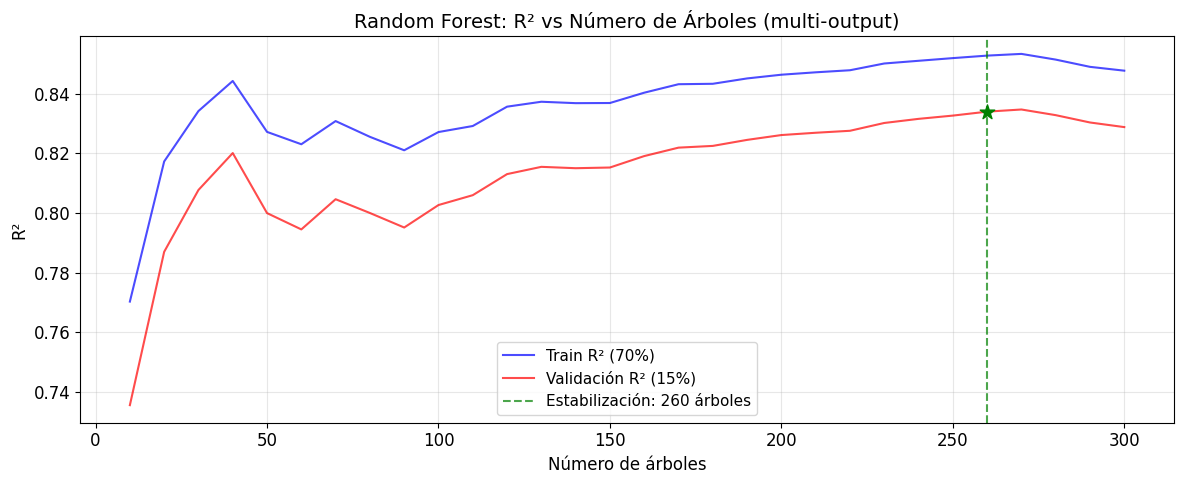

📊 Interpretación:
   - La curva de validación se estabiliza alrededor de 260 árboles.
   - El pico inicial (pocos árboles) es inestable y no representativo.
   - Se selecciona el punto de estabilización, no el máximo puntual.
   - Gap train-val = 0.0188 en el punto seleccionado.


In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.plot(TREE_RANGE, train_r2_hist, 'b-', alpha=0.7, linewidth=1.5, label='Train R² (70%)')
ax.plot(TREE_RANGE, val_r2_hist, 'r-', alpha=0.7, linewidth=1.5, label='Validación R² (15%)')
ax.axvline(x=best_n_trees, color='green', linestyle='--', alpha=0.7,
           label=f'Estabilización: {best_n_trees} árboles')
ax.scatter([best_n_trees], [val_r2_hist[best_val_idx]], color='green', s=120, zorder=5, marker='*')

ax.set_title('Random Forest: R² vs Número de Árboles (multi-output)', fontsize=14)
ax.set_xlabel('Número de árboles')
ax.set_ylabel('R²')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = train_r2_hist[best_val_idx] - val_r2_hist[best_val_idx]
print(f'📊 Interpretación:')
print(f'   - La curva de validación se estabiliza alrededor de {best_n_trees} árboles.')
print(f'   - El pico inicial (pocos árboles) es inestable y no representativo.')
print(f'   - Se selecciona el punto de estabilización, no el máximo puntual.')
print(f'   - Gap train-val = {gap:.4f} en el punto seleccionado.')

#### SGD Regressor: Convergencia con Early Stopping

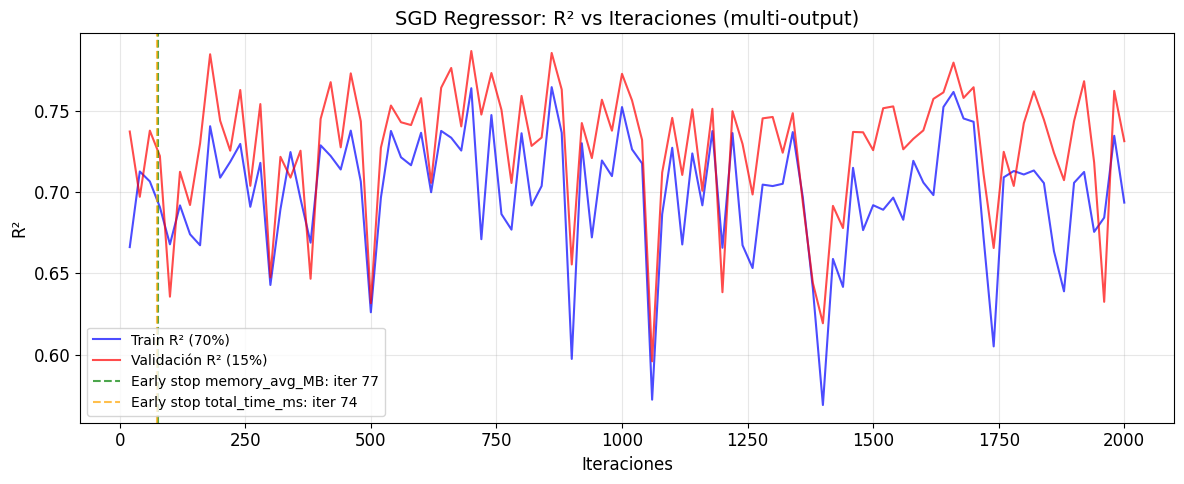

📊 Las líneas verticales indican dónde early_stopping detuvo cada sub-modelo.
   Train R² usa el 70% de entrenamiento, Validación R² usa el 15% separado.


In [12]:
# Gráfica de convergencia SGD por iteración
# Re-entrenar con diferentes iteraciones para capturar la curva

MAX_ITER_PLOT = 2000
STEP = 20

# Normalizar manualmente para esta gráfica
scaler_plot = StandardScaler()
X_train_plot = scaler_plot.fit_transform(X_train)
X_val_plot = scaler_plot.transform(X_val)

sgd_iter_points = []
sgd_train_r2 = []
sgd_val_r2 = []

for n_iter in range(STEP, MAX_ITER_PLOT + 1, STEP):
    temp_model = MultiOutputRegressor(
        SGDRegressor(
            loss='squared_error', penalty='elasticnet',
            alpha=0.001, l1_ratio=0.15,
            learning_rate='adaptive', eta0=0.01,
            max_iter=n_iter, tol=None,
            random_state=RANDOM_STATE
        )
    )
    temp_model.fit(X_train_plot, y_train)
    sgd_iter_points.append(n_iter)
    sgd_train_r2.append(r2_score(y_train, temp_model.predict(X_train_plot)))
    sgd_val_r2.append(r2_score(y_val, temp_model.predict(X_val_plot)))

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(sgd_iter_points, sgd_train_r2, 'b-', alpha=0.7, linewidth=1.5, label='Train R² (70%)')
ax.plot(sgd_iter_points, sgd_val_r2, 'r-', alpha=0.7, linewidth=1.5, label='Validación R² (15%)')

# Marcar donde paró early_stopping en el modelo final
for t_idx, t_name in enumerate(TARGET_COLS):
    es_iter = sgd_pipeline.named_steps['model'].estimators_[t_idx].n_iter_
    ax.axvline(x=es_iter, color='green' if t_idx == 0 else 'orange',
               linestyle='--', alpha=0.7,
               label=f'Early stop {t_name}: iter {es_iter}')

ax.set_title('SGD Regressor: R² vs Iteraciones (multi-output)', fontsize=14)
ax.set_xlabel('Iteraciones')
ax.set_ylabel('R²')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('📊 Las líneas verticales indican dónde early_stopping detuvo cada sub-modelo.')
print('   Train R² usa el 70% de entrenamiento, Validación R² usa el 15% separado.')

**Interpretación de la gráfica SGD:**

La gráfica muestra el R² del SGD Regressor multi-output (prediciendo `memory_avg_MB` y `total_time_ms` simultáneamente) en función del número de iteraciones.

- **Curva azul (Train 70%):** R² calculado sobre los datos de entrenamiento.
- **Curva roja (Validación 15%):** R² calculado sobre datos que el modelo nunca vio durante el entrenamiento.
- **Líneas verticales (Early Stop):** Indican la iteración donde `early_stopping` detuvo cada sub-modelo interno del `MultiOutputRegressor` (uno para `memory_avg_MB` y otro para `total_time_ms`).

**¿Qué se observa?**

- Ambas curvas oscilan significativamente. Esto es **esperable** en SGD: al ser estocástico, cada iteración actualiza los pesos con un subconjunto aleatorio de datos, lo que introduce ruido en la convergencia.
- Las curvas de train y validación se mantienen en un rango similar (~0.65–0.78), lo que indica que **no hay sobreajuste grave** — el modelo no memoriza el train.
- El R² del SGD es inferior al del Random Forest. Esto confirma que la relación entre configuración y métricas del trade-off **no es puramente lineal** — hay interacciones entre variables que un modelo lineal no puede capturar (ej: el efecto del batch size depende del modelo y la GPU).
- El `early_stopping` detiene el entrenamiento tempranamente (iteraciones ~70-80) porque detecta que la validación interna del SGD no mejora. Sin embargo, la gráfica muestra que iterar más no mejora significativamente — el modelo lineal ya capturó lo que puede capturar.

**Conclusión:** El SGD Regressor sirve como **línea base interpretable** pero tiene limitaciones inherentes al ser lineal. El Random Forest captura mejor las relaciones complejas del trade-off.

---
## 7. Tabla Comparativa (Test Set)

In [13]:
rows = []
for t_idx, t_name in enumerate(TARGET_COLS):
    unit = 'MB' if 'memory' in t_name else 'ms'
    y_te = y_test[:, t_idx]

    sgd_r2 = r2_score(y_te, sgd_pred_test[:, t_idx])
    sgd_mae = mean_absolute_error(y_te, sgd_pred_test[:, t_idx])
    sgd_rmse = np.sqrt(mean_squared_error(y_te, sgd_pred_test[:, t_idx]))

    rf_r2 = r2_score(y_te, rf_pred_test[:, t_idx])
    rf_mae = mean_absolute_error(y_te, rf_pred_test[:, t_idx])
    rf_rmse = np.sqrt(mean_squared_error(y_te, rf_pred_test[:, t_idx]))

    rows.append({
        'Target': t_name,
        'SGD R²': sgd_r2,
        'RF R²':  rf_r2,
        f'SGD MAE ({unit})':  sgd_mae,
        f'RF MAE ({unit})':   rf_mae,
        f'SGD RMSE ({unit})': sgd_rmse,
        f'RF RMSE ({unit})':  rf_rmse,
        'Mejor (por R²)': 'RF' if rf_r2 > sgd_r2 else 'SGD',
    })

df_comp = pd.DataFrame(rows)

# R² globales multi-output
sgd_global_r2 = r2_score(y_test, sgd_pred_test)
rf_global_r2  = r2_score(y_test, rf_pred_test)

# ================================================================
# Tabla estilizada: énfasis en R²
# ================================================================
r2_cols = ['SGD R²', 'RF R²']
mae_cols = [c for c in df_comp.columns if 'MAE' in c]
rmse_cols = [c for c in df_comp.columns if 'RMSE' in c]

styled = (
    df_comp.style
        .format({c: '{:.4f}' for c in r2_cols})
        .format({c: '{:.2f}'  for c in mae_cols + rmse_cols})
        .background_gradient(subset=r2_cols, cmap='YlGn', vmin=0.0, vmax=1.0)
        .set_properties(subset=r2_cols, **{
            'font-weight': '700',
            'font-size': '14px',
            'text-align': 'center',
            'border': '1px solid #bbb',
        })
        .set_properties(subset=mae_cols + rmse_cols, **{
            'text-align': 'center',
            'color': '#555',
        })
        .set_properties(subset=['Mejor (por R²)'], **{
            'font-weight': '700',
            'color': '#1a5276',
            'text-align': 'center',
            'background-color': '#eaf2f8',
        })
        .set_table_styles([
            {'selector': 'th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', '700'),
                       ('text-align', 'center'),
                       ('padding', '8px 12px'),
                       ('border', '1px solid #1a252f')]},
            {'selector': 'td',
             'props': [('padding', '8px 12px')]},
            {'selector': 'caption',
             'props': [('caption-side', 'top'),
                       ('font-size', '15px'),
                       ('font-weight', '700'),
                       ('color', '#2c3e50'),
                       ('padding', '8px 0')]},
        ])
        .hide(axis='index')
        .set_caption('📊 Comparación SGD vs Random Forest — Test Set (15%) · foco en R²')
)

display(styled)

print('─' * 70)
print(f'R² GLOBAL multi-output (test):')
print(f'   SGD: {sgd_global_r2:.4f}')
print(f'   RF:  {rf_global_r2:.4f}   ← {"mejor" if rf_global_r2 > sgd_global_r2 else "peor"}')
print()
print(f'R² medio en Cross-Validation (5-Fold sobre train):')
print(f'   SGD: {sgd_cv_scores.mean():.4f} ± {sgd_cv_scores.std():.4f}')
print(f'   RF:  {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')
print('─' * 70)


Target,SGD R²,RF R²,SGD MAE (MB),RF MAE (MB),SGD RMSE (MB),RF RMSE (MB),Mejor (por R²),SGD MAE (ms),RF MAE (ms),SGD RMSE (ms),RF RMSE (ms)
memory_avg_MB,0.876552,0.847098,245.97,213.22,316.80,352.58,SGD,nan,nan,nan,nan
total_time_ms,0.642752,0.885486,nan,nan,nan,nan,RF,5521.51,2424.15,9557.44,5411.11


──────────────────────────────────────────────────────────────────────
R² GLOBAL multi-output (test):
   SGD: 0.7597
   RF:  0.8663   ← mejor

R² medio en Cross-Validation (5-Fold sobre train):
   SGD: 0.7825 ± 0.0280
   RF:  0.8452 ± 0.0227
──────────────────────────────────────────────────────────────────────


### Gráficas de Calibración (Predicho vs Real)

Cada gráfica muestra la calibración para un modelo (SGD o RF) y un target (`memory_avg_MB` o `total_time_ms`). Cada punto es una configuración del test set; la línea roja es el ideal `y = x`.


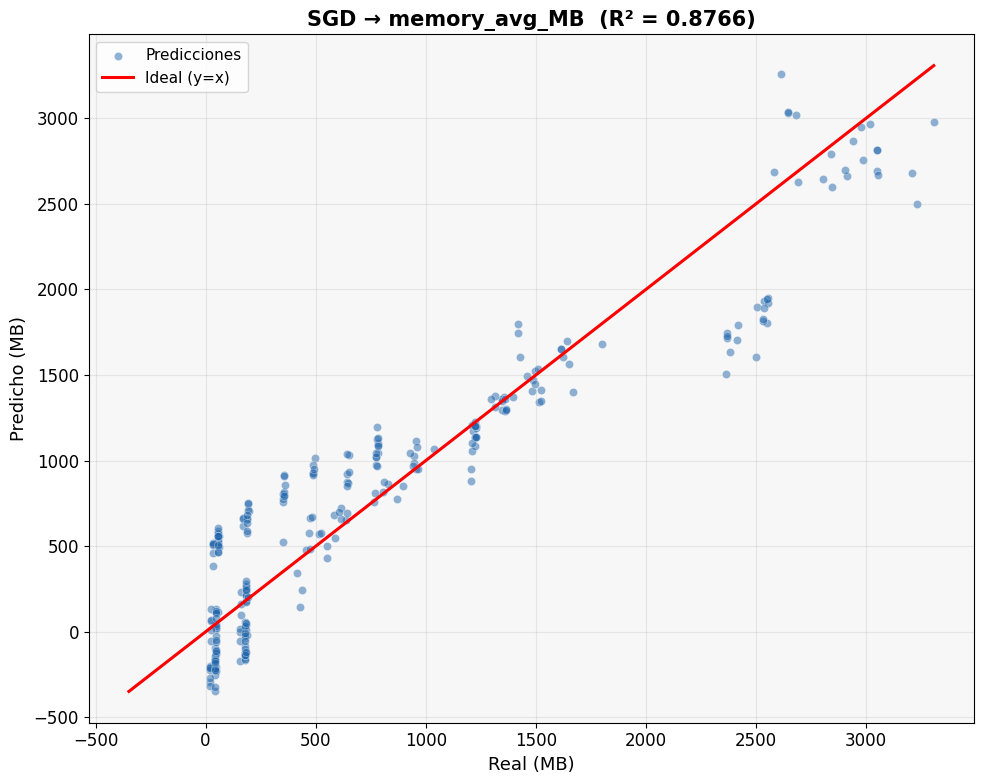

In [14]:
# Calibración SGD → memory_avg_MB
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

t_idx = TARGET_COLS.index('memory_avg_MB')
t_name = 'memory_avg_MB'
unit = 'MB'
y_te = y_test[:, t_idx]

ax.scatter(y_te, sgd_pred_test[:, t_idx], alpha=0.5, s=35,
           c='#2166ac', edgecolors='white', linewidths=0.4, label='Predicciones')
lims = [min(y_te.min(), sgd_pred_test[:, t_idx].min()),
        max(y_te.max(), sgd_pred_test[:, t_idx].max())]
ax.plot(lims, lims, 'r-', linewidth=2.2, label='Ideal (y=x)', zorder=10)

r2 = r2_score(y_te, sgd_pred_test[:, t_idx])
ax.set_xlabel(f'Real ({unit})', fontsize=13)
ax.set_ylabel(f'Predicho ({unit})', fontsize=13)
ax.set_title(f'SGD → {t_name}  (R² = {r2:.4f})', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.25)
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.show()


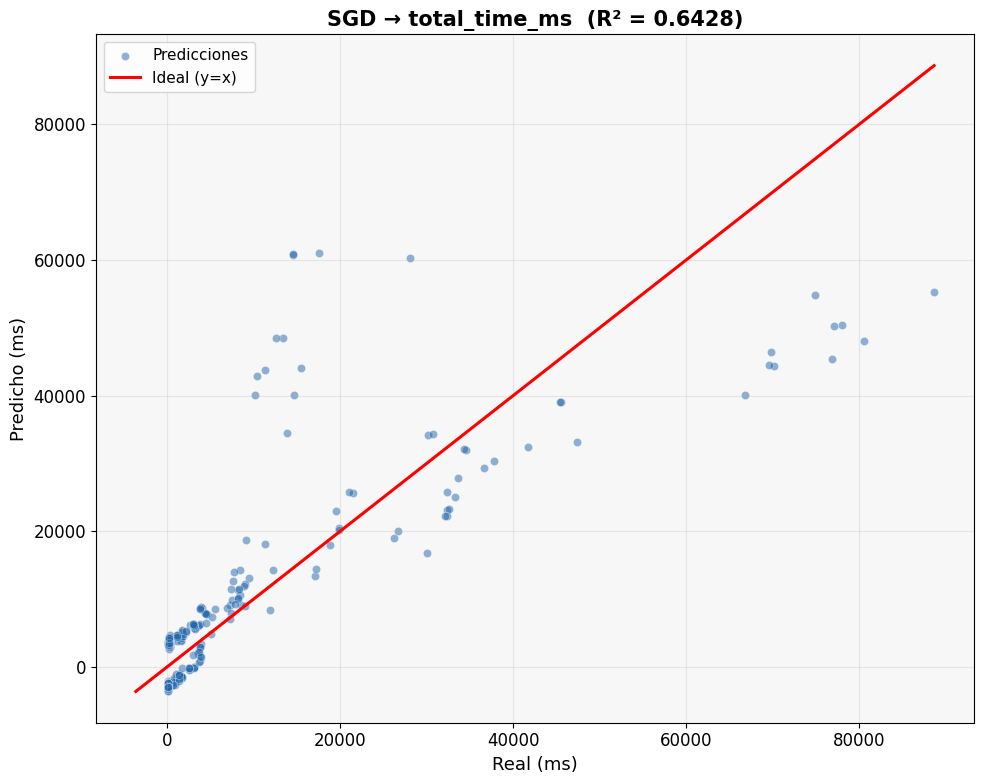

In [15]:
# Calibración SGD → total_time_ms
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

t_idx = TARGET_COLS.index('total_time_ms')
t_name = 'total_time_ms'
unit = 'ms'
y_te = y_test[:, t_idx]

ax.scatter(y_te, sgd_pred_test[:, t_idx], alpha=0.5, s=35,
           c='#2166ac', edgecolors='white', linewidths=0.4, label='Predicciones')
lims = [min(y_te.min(), sgd_pred_test[:, t_idx].min()),
        max(y_te.max(), sgd_pred_test[:, t_idx].max())]
ax.plot(lims, lims, 'r-', linewidth=2.2, label='Ideal (y=x)', zorder=10)

r2 = r2_score(y_te, sgd_pred_test[:, t_idx])
ax.set_xlabel(f'Real ({unit})', fontsize=13)
ax.set_ylabel(f'Predicho ({unit})', fontsize=13)
ax.set_title(f'SGD → {t_name}  (R² = {r2:.4f})', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.25)
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.show()


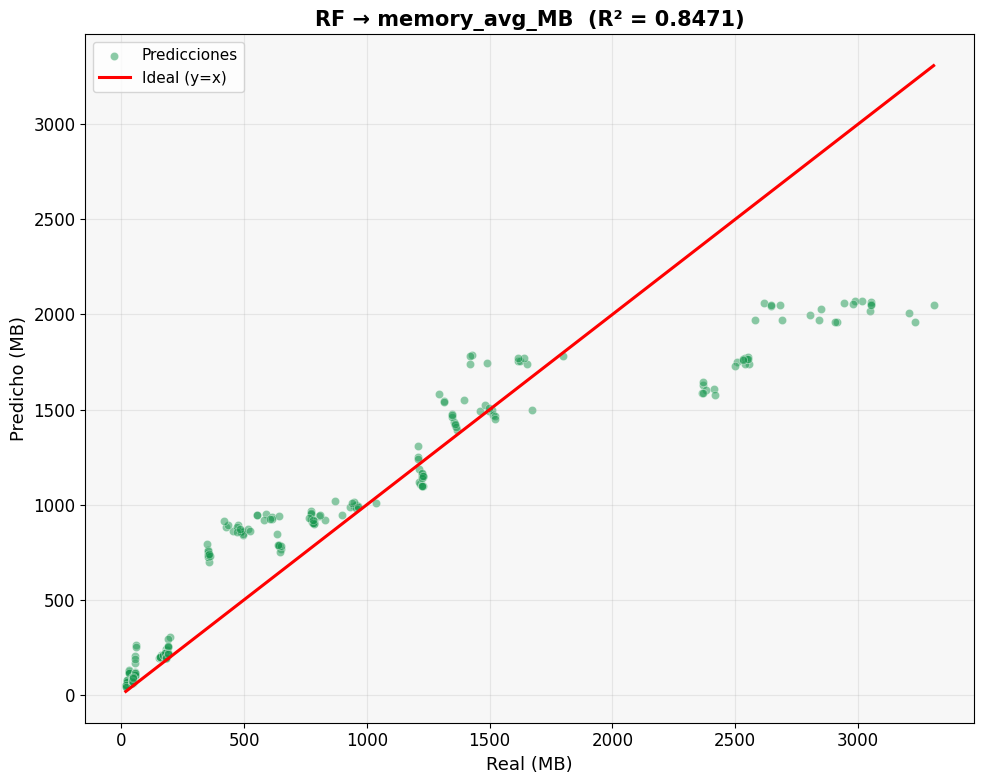

In [16]:
# Calibración RF → memory_avg_MB
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

t_idx = TARGET_COLS.index('memory_avg_MB')
t_name = 'memory_avg_MB'
unit = 'MB'
y_te = y_test[:, t_idx]

ax.scatter(y_te, rf_pred_test[:, t_idx], alpha=0.5, s=35,
           c='#1a9850', edgecolors='white', linewidths=0.4, label='Predicciones')
lims = [min(y_te.min(), rf_pred_test[:, t_idx].min()),
        max(y_te.max(), rf_pred_test[:, t_idx].max())]
ax.plot(lims, lims, 'r-', linewidth=2.2, label='Ideal (y=x)', zorder=10)

r2 = r2_score(y_te, rf_pred_test[:, t_idx])
ax.set_xlabel(f'Real ({unit})', fontsize=13)
ax.set_ylabel(f'Predicho ({unit})', fontsize=13)
ax.set_title(f'RF → {t_name}  (R² = {r2:.4f})', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.25)
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.show()


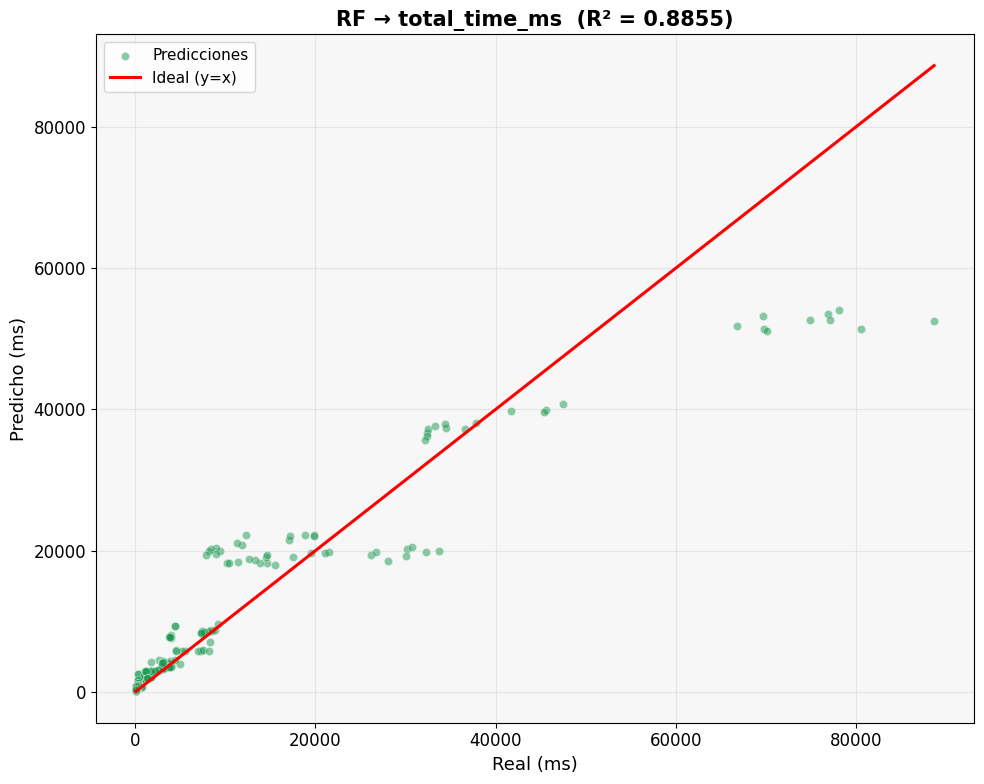

In [17]:
# Calibración RF → total_time_ms
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

t_idx = TARGET_COLS.index('total_time_ms')
t_name = 'total_time_ms'
unit = 'ms'
y_te = y_test[:, t_idx]

ax.scatter(y_te, rf_pred_test[:, t_idx], alpha=0.5, s=35,
           c='#1a9850', edgecolors='white', linewidths=0.4, label='Predicciones')
lims = [min(y_te.min(), rf_pred_test[:, t_idx].min()),
        max(y_te.max(), rf_pred_test[:, t_idx].max())]
ax.plot(lims, lims, 'r-', linewidth=2.2, label='Ideal (y=x)', zorder=10)

r2 = r2_score(y_te, rf_pred_test[:, t_idx])
ax.set_xlabel(f'Real ({unit})', fontsize=13)
ax.set_ylabel(f'Predicho ({unit})', fontsize=13)
ax.set_title(f'RF → {t_name}  (R² = {r2:.4f})', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.25)
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.show()


**Interpretación de las gráficas de calibración:**

Cada punto representa una configuración experimental del test set. La línea roja es el **ideal** (`y = x`: predicho igual al real). Cuanto más cerca de la línea estén los puntos, mejor es la calibración del modelo. El Random Forest concentra los puntos sobre la diagonal (R² alto y disperso homogéneo), mientras que el SGD muestra más desviación, sobre todo en los valores grandes de memoria y tiempo (donde las VGG-16 dominan la escala).


### 8.2 Configuraciones Óptimas y Estrategias de Referencia

| Estrategia |
|---|
| **(i) Sin rematerialización** |
| **(ii) Uniform Segment Checkpointing** |
| **(iii) Checkpoint selectivo** |


In [18]:
capa_cols = [c for c in df.columns if c.startswith('capa_checkpoint_')]
model_cols_list = [c for c in df.columns if c.startswith('model_')]

df_analysis = df.copy()

# Identificar modelo y GPU PRIMERO (se usa para la clasificación)
df_analysis['modelo'] = ''
for mc in model_cols_list:
    df_analysis.loc[df_analysis[mc] == 1, 'modelo'] = mc.replace('model_', '')
df_analysis['gpu'] = np.where(
    df_analysis['gpu_name_NVIDIA GeForce GTX TITAN X'] == 1, 'NVIDIA', 'AMD'
)

# ================================================================
# CLASIFICACIÓN DE ESTRATEGIAS — SOLO PARA CNN
# ================================================================
# Por defecto todo es 'checkpoint_selectivo'
df_analysis['strategy'] = 'checkpoint_selectivo'

# (i) Sin rematerialización: mode_normal=1 y ningún checkpoint activo
df_analysis.loc[
    (df_analysis['mode_normal'] == 1) & (df_analysis[capa_cols].sum(axis=1) == 0),
    'strategy'
] = 'sin_rematerializacion'

# (ii) Uniform Segment Checkpointing — específico por modelo CNN:
#   - VGG-16 : capa_checkpoint_block1_block2_block3_block4_block5 = 1
#   - LeNet-5: capa_checkpoint_conv1_conv2 = 1
#   - AlexNet: capa_checkpoint_conv1_conv2_conv3_conv4_conv5 = 1
mask_vgg_uniform = (
    (df_analysis['modelo'] == 'VGG-16') &
    (df_analysis['capa_checkpoint_block1_block2_block3_block4_block5'] == 1)
)
mask_lenet_uniform = (
    (df_analysis['modelo'] == 'LeNet-5') &
    (df_analysis['capa_checkpoint_conv1_conv2'] == 1)
)
mask_alex_uniform = (
    (df_analysis['modelo'] == 'AlexNet') &
    (df_analysis['capa_checkpoint_conv1_conv2_conv3_conv4_conv5'] == 1)
)
df_analysis.loc[mask_vgg_uniform | mask_lenet_uniform | mask_alex_uniform,
                'strategy'] = 'uniform_segment'

# Identificar configuración de checkpoint
def get_cp_config(row):
    active = [c.replace('capa_checkpoint_', '') for c in capa_cols if row[c] == 1]
    return '+'.join(active) if active else 'ninguno'
df_analysis['checkpoint_config'] = df_analysis.apply(get_cp_config, axis=1)

# Para los análisis de 8.2 quedamos SOLO con CNN
cnn_models = ['LeNet-5', 'AlexNet', 'VGG-16']
df_analysis_cnn = df_analysis[df_analysis['modelo'].isin(cnn_models)].copy()

print('Distribución de estrategias (SOLO CNN):')
print(df_analysis_cnn['strategy'].value_counts())
print(f'\nModelos CNN: {sorted(df_analysis_cnn["modelo"].unique())}')
print(f'GPUs: {sorted(df_analysis_cnn["gpu"].unique())}')


Distribución de estrategias (SOLO CNN):
strategy
checkpoint_selectivo     1064
sin_rematerializacion      96
uniform_segment            94
Name: count, dtype: int64

Modelos CNN: ['AlexNet', 'LeNet-5', 'VGG-16']
GPUs: ['AMD', 'NVIDIA']


In [19]:
# Análisis por modelo (CNN): mejores configuraciones separadas por GPU y batch
print('=' * 100)
print('ANÁLISIS POR MODELO — CNN')
print('=' * 100)

modelos_cnn = ['LeNet-5', 'AlexNet', 'VGG-16']

# Configuraciones de checkpoint EXCLUIDAS del análisis por modelo
excluded_cp_by_model = {
    'LeNet-5': {'conv1_conv2_fc'},
    'AlexNet': {'full'},
    'VGG-16':  {'full'},
}

for modelo_name in modelos_cnn:
    mod_df = df_analysis_cnn[df_analysis_cnn['modelo'] == modelo_name]
    if len(mod_df) == 0:
        continue

    # Excluir los checkpoint_config indicados por requerimiento
    excluded = excluded_cp_by_model.get(modelo_name, set())
    mod_df = mod_df[~mod_df['checkpoint_config'].isin(excluded)]

    print(f'\n{"#"*90}')
    print(f'📊 {modelo_name} ({len(mod_df)} configuraciones, excluyendo {sorted(excluded)})')
    print(f'{"#"*90}')

    for gpu_name in ['NVIDIA', 'AMD']:
        gpu_df = mod_df[mod_df['gpu'] == gpu_name]
        if len(gpu_df) == 0:
            continue

        for bs in sorted(gpu_df['batch_size'].unique()):
            sub = gpu_df[gpu_df['batch_size'] == bs]
            remat_sub = sub[sub['strategy'] != 'sin_rematerializacion']
            if len(remat_sub) == 0:
                continue

            print(f'\n  ── GPU: {gpu_name}  |  batch: {int(bs)}  '
                  f'({len(sub)} configs totales, {len(remat_sub)} con remat)')
            print(f'     🏆 Top 3 configuraciones con mayor ahorro de memoria:')
            top3 = remat_sub.nlargest(3, 'ahorro_memoria_pct')[
                ['modelo', 'gpu', 'batch_size', 'checkpoint_config', 'strategy',
                 'ahorro_memoria_pct', 'memory_avg_MB', 'total_time_ms',
                 'factor_recompute']
            ].reset_index(drop=True)
            display(top3)


ANÁLISIS POR MODELO — CNN

##########################################################################################
📊 LeNet-5 (160 configuraciones, excluyendo ['conv1_conv2_fc'])
##########################################################################################

  ── GPU: NVIDIA  |  batch: 16  (20 configs totales, 16 con remat)
     🏆 Top 3 configuraciones con mayor ahorro de memoria:


,modelo,gpu,batch_size,checkpoint_config,strategy,ahorro_memoria_pct,memory_avg_MB,total_time_ms,factor_recompute
0,LeNet-5,NVIDIA,16,conv1_conv2,uniform_segment,0.5391,18.45,204.9298,1.8427
1,LeNet-5,NVIDIA,16,conv1,checkpoint_selectivo,0.4313,18.47,191.0704,1.3330
2,LeNet-5,NVIDIA,16,conv1_conv2,uniform_segment,0.2703,18.45,206.9706,1.8427



  ── GPU: NVIDIA  |  batch: 32  (20 configs totales, 16 con remat)
     🏆 Top 3 configuraciones con mayor ahorro de memoria:


,modelo,gpu,batch_size,checkpoint_config,strategy,ahorro_memoria_pct,memory_avg_MB,total_time_ms,factor_recompute
0,LeNet-5,NVIDIA,32,conv1_conv2,uniform_segment,0.9223,20.41,266.0282,1.8427
1,LeNet-5,NVIDIA,32,conv1,checkpoint_selectivo,0.7767,20.44,248.4081,1.3330
2,LeNet-5,NVIDIA,32,conv1_conv2,uniform_segment,0.5363,20.40,268.8239,1.8427



  ── GPU: NVIDIA  |  batch: 64  (20 configs totales, 16 con remat)
     🏆 Top 3 configuraciones con mayor ahorro de memoria:


...

,modelo,gpu,batch_size,checkpoint_config,strategy,ahorro_memoria_pct,memory_avg_MB,total_time_ms,factor_recompute
0,VGG-16,AMD,32,block1_block2_block3_block4_block5,uniform_segment,18.6069,849.02,8528.4139,1.9885
1,VGG-16,AMD,32,block1_block2_block3_block4,checkpoint_selectivo,18.1745,853.53,8453.4550,1.9000
2,VGG-16,AMD,32,block1_block2_block3,checkpoint_selectivo,16.5946,870.01,9138.7016,1.6049



  ── GPU: AMD  |  batch: 64  (64 configs totales, 60 con remat)
     🏆 Top 3 configuraciones con mayor ahorro de memoria:


,modelo,gpu,batch_size,checkpoint_config,strategy,ahorro_memoria_pct,memory_avg_MB,total_time_ms,factor_recompute
0,VGG-16,AMD,64,block1_block2_block3_block4_block5,uniform_segment,21.3960,1426.97,28446.4772,1.9885
1,VGG-16,AMD,64,block1_block2_block3_block4,checkpoint_selectivo,20.9233,1435.55,32818.6149,1.9000
2,VGG-16,AMD,64,block1_block2_block3,checkpoint_selectivo,19.1055,1468.55,27120.0200,1.6049



  ── GPU: AMD  |  batch: 128  (55 configs totales, 51 con remat)
     🏆 Top 3 configuraciones con mayor ahorro de memoria:


,modelo,gpu,batch_size,checkpoint_config,strategy,ahorro_memoria_pct,memory_avg_MB,total_time_ms,factor_recompute
0,VGG-16,AMD,128,block1_block2_block3_block4_block5,uniform_segment,22.9368,2599.35,17283.6874,1.9885
1,VGG-16,AMD,128,block1_block2_block3_block4,checkpoint_selectivo,22.4387,2616.15,28073.1830,1.9000
2,VGG-16,AMD,128,block1_block2_block3,checkpoint_selectivo,20.5149,2681.04,17565.1077,1.6049


### 8.3 Validación Estadística: Comparación entre Estrategias (solo CNN)

Se aplica el protocolo estadístico definido en la sección 5.3 para determinar si las diferencias entre estrategias son significativas. **El análisis se restringe a los modelos CNN** (LeNet-5, AlexNet y VGG-16), puesto que son las arquitecturas donde las tres estrategias de rematerialización están bien definidas y donde la comparación tiene sentido físico (en los MLP el `uniform_segment` específico por arquitectura no aplica y el ahorro de memoria es despreciable por construcción).

**Protocolo:**
1. **Levene** — contrasta si las varianzas de las tres estrategias son homogéneas.
2. **ANOVA / Kruskal-Wallis** — contrasta diferencias entre medias (o medianas); se usa ANOVA si Levene no rechaza homogeneidad, Kruskal-Wallis en caso contrario.
3. **Tukey HSD** — post-hoc para identificar qué pares de estrategias difieren, controlando el error tipo I acumulado.


In [28]:
# Restringir el análisis estadístico a modelos CNN solamente
modelos_cnn_stats = ['LeNet-5', 'AlexNet', 'VGG-16']
df_stats_src = df_analysis[df_analysis['modelo'].isin(modelos_cnn_stats)].copy()

print(f'Total de configuraciones CNN analizadas: {len(df_stats_src)}')
print(f'Modelos CNN: {modelos_cnn_stats}')

strategies = df_stats_src['strategy'].unique()
print(f'\nEstrategias: {list(strategies)}')
print(f'α = 0.05')
print('=' * 90)

statistical_results = []

for metric in TARGET_COLS:
    unit = 'MB' if 'memory' in metric else 'ms'
    print(f'\n{"="*90}')
    print(f'📊 Variable: {metric} ({unit})  —  solo CNN')
    print('-' * 90)

    groups = [df_stats_src.loc[df_stats_src['strategy'] == s, metric].values
              for s in strategies]

    for s, g in zip(strategies, groups):
        print(f'  {s:30s}: n={len(g):4d}, media={g.mean():12.2f} {unit}, '
              f'std={g.std():12.2f} {unit}')

    # 1. Levene
    levene_stat, levene_p = levene(*groups)
    homogeneous = levene_p > 0.05
    print(f'\n  [1] Levene: W={levene_stat:.4f}, p={levene_p:.6f}')
    print(f'      → {"Varianzas homogéneas ✅" if homogeneous else "Varianzas NO homogéneas ❌"}')

    # 2. ANOVA o Kruskal-Wallis
    if homogeneous:
        test_stat, test_p = f_oneway(*groups)
        test_name = 'ANOVA'
    else:
        test_stat, test_p = kruskal(*groups)
        test_name = 'Kruskal-Wallis'

    significant = test_p < 0.05
    print(f'\n  [2] {test_name}: stat={test_stat:.4f}, p={test_p:.6f}')
    print(f'      → {"Diferencia SIGNIFICATIVA ✅" if significant else "No significativa ❌"}')

    result = {
        'metric': metric, 'levene_p': round(levene_p, 6),
        'varianzas_homogeneas': homogeneous, 'test_usado': test_name,
        'test_p': round(test_p, 6), 'significativo': significant
    }

    # 3. Tukey HSD
    if significant:
        all_values = np.concatenate(groups)
        all_labels = np.concatenate([np.repeat(s, len(g)) for s, g in zip(strategies, groups)])
        tukey = pairwise_tukeyhsd(all_values, all_labels, alpha=0.05)
        print(f'\n  [3] Tukey HSD Post-hoc (solo CNN):')
        print(f'  {tukey}')
    else:
        print(f'\n  [3] Tukey HSD: No se aplica')

    statistical_results.append(result)


Total de configuraciones CNN analizadas: 1254
Modelos CNN: ['LeNet-5', 'AlexNet', 'VGG-16']

Estrategias: ['sin_rematerializacion', 'checkpoint_selectivo', 'uniform_segment']
α = 0.05

📊 Variable: memory_avg_MB (MB)  —  solo CNN
------------------------------------------------------------------------------------------
  sin_rematerializacion         : n=  96, media=      954.69 MB, std=      953.41 MB
  checkpoint_selectivo          : n=1064, media=     1156.07 MB, std=      881.55 MB
  uniform_segment               : n=  94, media=      829.85 MB, std=      814.77 MB

  [1] Levene: W=0.7054, p=0.494127
      → Varianzas homogéneas ✅

  [2] ANOVA: stat=7.6246, p=0.000511
      → Diferencia SIGNIFICATIVA ✅

  [3] Tukey HSD Post-hoc (solo CNN):
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
        group1                group2         meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------

In [21]:
df_stats = pd.DataFrame(statistical_results)
print('Resumen de pruebas estadísticas:')
display(df_stats)

Resumen de pruebas estadísticas:


,metric,levene_p,varianzas_homogeneas,test_usado,test_p,significativo
0,memory_avg_MB,0.494127,True,ANOVA,0.000511,True
1,total_time_ms,0.329695,True,ANOVA,0.150101,False


**Interpretación del resumen:**

- Si `significativo = True` para una métrica, significa que la estrategia de rematerialización **sí afecta** esa variable de forma estadísticamente significativa.
- La prueba de Tukey HSD muestra **qué pares** difieren. Por ejemplo, si `sin_rematerializacion` vs `uniform_segment` tiene `reject=True`, significa que el consumo de memoria (o tiempo) es significativamente diferente entre ambas.
- Cuando las varianzas no son homogéneas (Levene rechazado), se usa Kruskal-Wallis en lugar de ANOVA — es más conservador pero no asume normalidad ni varianzas iguales.

### 8.4 Visualización Comparativa entre Estrategias (solo CNN)

Los boxplots permiten visualizar la distribución de cada métrica por estrategia. **El análisis se restringe a los modelos CNN** (LeNet-5, AlexNet y VGG-16), consistente con la Sección 8.3. Cada caja muestra:

- **Línea central:** mediana.
- **Caja:** rango intercuartílico (Q1 a Q3, el 50 % central de los datos).
- **Bigotes:** extensión hasta 1,5 × IQR.
- **Puntos fuera:** valores más allá de los bigotes (no son errores; son configuraciones de modelos grandes como VGG-16 con batch alto).

Si las cajas de dos estrategias **no se superponen** verticalmente, es un indicador visual de diferencia, lo cual debería coincidir con los resultados de las pruebas estadísticas.


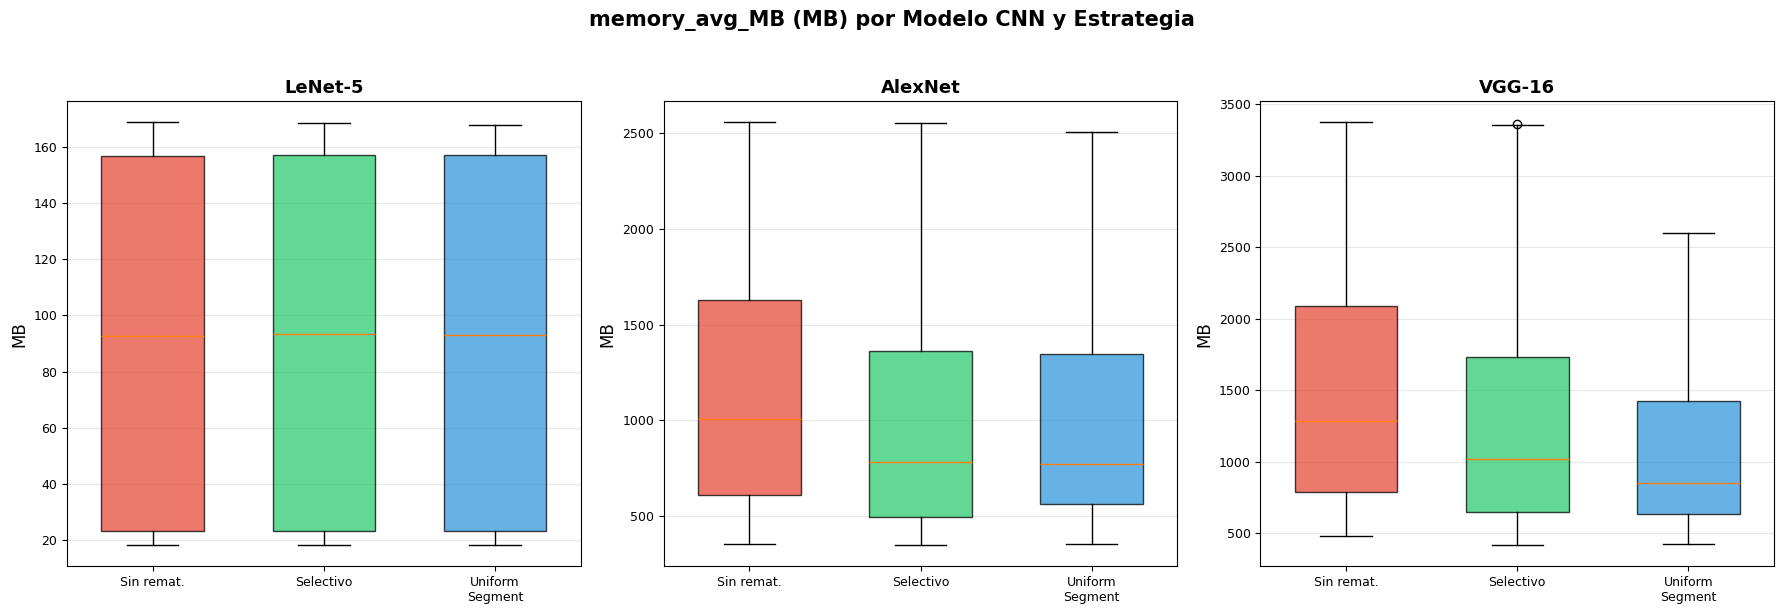

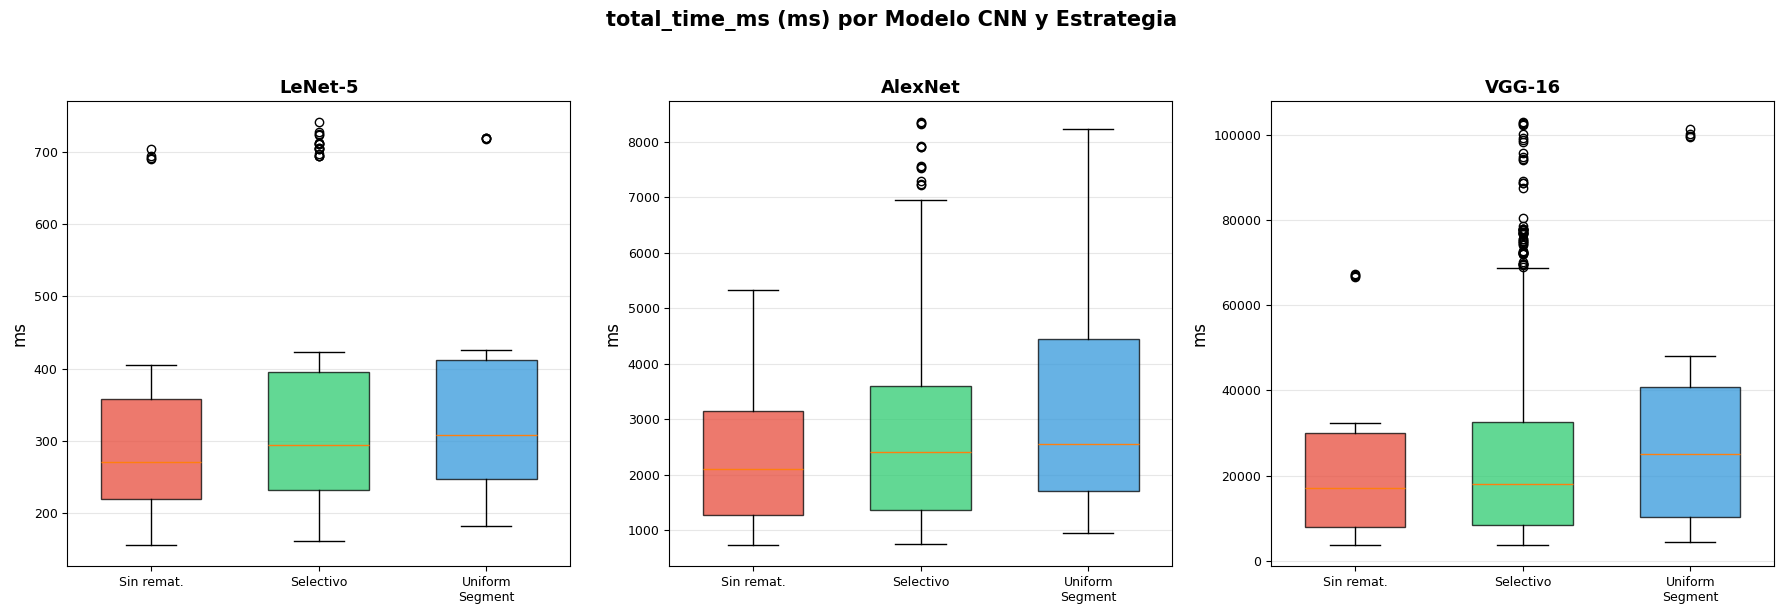

📊 Rojo: sin rematerialización | Verde: checkpoint selectivo | Azul: uniform segment
   Solo modelos CNN (LeNet-5, AlexNet, VGG-16), consistente con la Sección 8.3.


In [22]:
# Boxplots separados por modelo — SOLO CNN
strategies = ['sin_rematerializacion', 'checkpoint_selectivo', 'uniform_segment']
strat_labels = ['Sin remat.', 'Selectivo', 'Uniform\nSegment']
colors = {'sin_rematerializacion': '#e74c3c',
          'uniform_segment': '#3498db',
          'checkpoint_selectivo': '#2ecc71'}

cnn_models = ['LeNet-5', 'AlexNet', 'VGG-16']

for target_name in TARGET_COLS:
    unit = 'MB' if 'memory' in target_name else 'ms'
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, modelo_name in enumerate(cnn_models):
        ax = axes[idx]
        mod_df = df_analysis[df_analysis['modelo'] == modelo_name]

        data_to_plot = []
        labels_to_use = []
        colors_to_use = []
        for s, lbl in zip(strategies, strat_labels):
            subset = mod_df.loc[mod_df['strategy'] == s, target_name].values
            if len(subset) > 0:
                data_to_plot.append(subset)
                labels_to_use.append(lbl)
                colors_to_use.append(colors[s])

        if len(data_to_plot) > 0:
            bp = ax.boxplot(data_to_plot, labels=labels_to_use,
                            patch_artist=True, widths=0.6)
            for patch, color in zip(bp['boxes'], colors_to_use):
                patch.set_facecolor(color)
                patch.set_alpha(0.75)

        ax.set_title(f'{modelo_name}', fontsize=13, fontweight='bold')
        ax.set_ylabel(f'{unit}')
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(labelsize=9)

    plt.suptitle(f'{target_name} ({unit}) por Modelo CNN y Estrategia',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print('📊 Rojo: sin rematerialización | Verde: checkpoint selectivo | Azul: uniform segment')
print('   Solo modelos CNN (LeNet-5, AlexNet, VGG-16), consistente con la Sección 8.3.')


---
## 9. Escenarios Experimentales y Análisis Práctico

En esta sección se utiliza el **modelo Random Forest entrenado** para explorar escenarios prácticos del trade-off cómputo–memoria. Cada predicción del modelo se **verifica contra los datos reales** del dataset `Resultados_MLP_CNN.csv` (incluyendo `train_acc`, `val_acc` y `total_train_time_s`) para comprobar la veracidad de las predicciones.

Los escenarios se separan por tipo de modelo (MLP vs CNN), batch size y GPU.

### 9.1 Preparación de datos para los escenarios

In [29]:
# Preparar el dataset con columnas auxiliares
# (reutilizar df_analysis del bloque anterior si existe, o recrear)
if 'modelo' not in df_analysis.columns:
    model_cols_list = [c for c in df.columns if c.startswith('model_')]
    df_analysis['modelo'] = ''
    for mc in model_cols_list:
        df_analysis.loc[df_analysis[mc] == 1, 'modelo'] = mc.replace('model_', '')
    df_analysis['gpu'] = np.where(
        df_analysis['gpu_name_NVIDIA GeForce GTX TITAN X'] == 1, 'NVIDIA', 'AMD')

df_analysis['tiene_remat'] = df_analysis[capa_cols].sum(axis=1) > 0
df_analysis['compute_overhead_pct'] = (df_analysis['factor_recompute'] - 1) * 100

df_remat = df_analysis[df_analysis['tiene_remat']].copy()

print(f'Dataset: {len(df_analysis)} filas')
print(f'Con rematerialización: {len(df_remat)}')
print(f'Sin rematerialización: {(~df_analysis["tiene_remat"]).sum()}')

# Función auxiliar para predecir con RF y comparar con datos reales
def predecir_y_comparar(row_real, rf_model, feature_cols, target_cols):
    """Predice con RF y compara con valores reales."""
    X_input = row_real[feature_cols].values.reshape(1, -1)
    pred = rf_model.predict(X_input)[0]
    result = {}
    for t_idx, t_name in enumerate(target_cols):
        real = row_real[t_name]
        unit = 'MB' if 'memory' in t_name else 'ms'
        error_pct = abs(pred[t_idx] - real) / real * 100 if real != 0 else 0
        result[t_name] = {'real': real, 'predicho': pred[t_idx],
                          'error_pct': error_pct, 'unit': unit}
    return result

colors_model = {'VGG-16': '#e74c3c', 'AlexNet': '#3498db', 'LeNet-5': '#2ecc71',
                'MLP-3': '#f39c12', 'MLP-5': '#9b59b6', 'MLP-7': '#1abc9c'}

print('\n✅ Datos preparados')

Dataset: 1894 filas
Con rematerialización: 1702
Sin rematerialización: 192

✅ Datos preparados


### 9.2 Situación: Mejor combinación para máximo ahorro de memoria (por modelo)

**Pregunta:** Para cada modelo, GPU y **tamaño de batch**, ¿qué configuración de checkpoint logra el mayor ahorro de memoria?

Se comparan los valores **reales del dataset** del *baseline* (misma arquitectura, misma GPU, mismo batch, misma función de activación, sin rematerialización) contra los valores **reales del dataset** de la configuración óptima con rematerialización. Adicionalmente se muestra la predicción del Random Forest entrenado sobre esa configuración óptima, a modo de verificación.


In [24]:
# Mejor configuración por modelo, GPU, batch y activación
# Comparación dataset REAL (baseline sin remat) vs dataset REAL (mejor remat)
# + predicción del RF sobre la configuración óptima (a modo de verificación).
print('🏆 MEJOR AHORRO DE MEMORIA POR MODELO / GPU / BATCH')
print('=' * 120)

# Mapa de columnas de activación → nombre legible
act_cols = [c for c in df_analysis.columns if c.startswith('activation_')]
def get_activation(row):
    for c in act_cols:
        if row[c] == 1:
            return c.replace('activation_', '')
    return 'N/A'
df_analysis['activation'] = df_analysis.apply(get_activation, axis=1)
df_remat_local = df_analysis[df_analysis[capa_cols].sum(axis=1) > 0].copy()

for grupo, modelos in [('MLP', ['MLP-3', 'MLP-5', 'MLP-7']),
                        ('CNN', ['LeNet-5', 'AlexNet', 'VGG-16'])]:
    print(f'\n{"#"*120}')
    print(f'  {grupo}')
    print(f'{"#"*120}')

    for modelo_name in modelos:
        mod_remat = df_remat_local[df_remat_local['modelo'] == modelo_name]
        if len(mod_remat) == 0:
            continue

        print(f'\n{"─"*100}')
        print(f'📊 {modelo_name}')
        print(f'{"─"*100}')

        for gpu_name in ['NVIDIA', 'AMD']:
            gpu_df = mod_remat[mod_remat['gpu'] == gpu_name]
            if len(gpu_df) == 0:
                continue

            for bs in sorted(gpu_df['batch_size'].unique()):
                bs_df = gpu_df[gpu_df['batch_size'] == bs]
                if len(bs_df) == 0:
                    continue

                # Mejor configuración dentro del (modelo, gpu, batch)
                best_idx = bs_df['ahorro_memoria_pct'].idxmax()
                best = bs_df.loc[best_idx]
                act_best = best['activation']

                # Buscar el BASELINE REAL en el dataset:
                # mismo modelo, GPU, batch, activación y SIN rematerialización
                baseline = df_analysis[
                    (df_analysis['modelo'] == modelo_name) &
                    (df_analysis['gpu'] == gpu_name) &
                    (df_analysis['batch_size'] == bs) &
                    (df_analysis['activation'] == act_best) &
                    (df_analysis['mode_normal'] == 1) &
                    (df_analysis[capa_cols].sum(axis=1) == 0)
                ]

                if len(baseline) == 0:
                    print(f'\n  GPU: {gpu_name} | batch={int(bs)} | act={act_best}  '
                          f'(no se encontró baseline real en el dataset)')
                    continue
                base_row = baseline.iloc[0]

                # Predicción del RF sobre la configuración óptima
                pred = rf_final.predict(best[FEATURE_COLS].values.reshape(1, -1))[0]
                pred_mem, pred_tim = pred[0], pred[1]

                # Delta real (baseline real vs mejor remat real)
                delta_mem = best['memory_avg_MB'] - base_row['memory_avg_MB']
                delta_tim = best['total_time_ms'] - base_row['total_time_ms']
                dmem_pct = delta_mem / base_row['memory_avg_MB'] * 100
                dtim_pct = delta_tim / base_row['total_time_ms']  * 100

                print(f'\n  {modelo_name}, GPU: {gpu_name} | batch={int(bs)} | '
                      f'checkpoint: {best["checkpoint_config"]} | activación: {act_best}')
                print(f'    ─ BASELINE real (sin remat)   │ '
                      f'mem={base_row["memory_avg_MB"]:8.2f} MB │ '
                      f'time={base_row["total_time_ms"]:9.2f} ms')
                print(f'    ─ MEJOR REMAT real             │ '
                      f'mem={best["memory_avg_MB"]:8.2f} MB │ '
                      f'time={best["total_time_ms"]:9.2f} ms')
                print(f'    ─ Δ real (remat - baseline)    │ '
                      f'Δmem={delta_mem:+8.2f} MB ({dmem_pct:+5.1f}%) │ '
                      f'Δtime={delta_tim:+9.2f} ms ({dtim_pct:+5.1f}%)')
                print(f'    ─ RF predice (mejor remat)     │ '
                      f'mem={pred_mem:8.2f} MB │ '
                      f'time={pred_tim:9.2f} ms')
                err_mem = abs(pred_mem - best["memory_avg_MB"]) / best["memory_avg_MB"] * 100
                err_tim = abs(pred_tim - best["total_time_ms"]) / best["total_time_ms"] * 100
                print(f'    ─ Error RF sobre mejor remat   │ '
                      f'mem={err_mem:5.1f}%        │ '
                      f'time={err_tim:5.1f}%')


🏆 MEJOR AHORRO DE MEMORIA POR MODELO / GPU / BATCH

########################################################################################################################
  MLP
########################################################################################################################

────────────────────────────────────────────────────────────────────────────────────────────────────
📊 MLP-3
────────────────────────────────────────────────────────────────────────────────────────────────────

  MLP-3, GPU: NVIDIA | batch=16 | checkpoint: fc2 | activación: leaky_relu
    ─ BASELINE real (sin remat)   │ mem=   53.14 MB │ time=   141.04 ms
    ─ MEJOR REMAT real             │ mem=   51.13 MB │ time=   183.28 ms
    ─ Δ real (remat - baseline)    │ Δmem=   -2.01 MB ( -3.8%) │ Δtime=   +42.24 ms (+29.9%)
    ─ RF predice (mejor remat)     │ mem=  117.12 MB │ time=  1176.83 ms
    ─ Error RF sobre mejor remat   │ mem=129.1%        │ time=542.1%

  MLP-3, GPU: NVIDIA | batch=32 

**Interpretación:**

- El RF predice `memory_avg_MB` y `total_time_ms` para cada configuración óptima. El error porcentual indica qué tan precisa es la predicción.
- Las métricas de entrenamiento (`train_acc`, `val_acc`) confirman que la rematerialización **no afecta la calidad del modelo entrenado** — solo afecta memoria y tiempo.
- Los mayores ahorros se concentran en **VGG-16** (hasta ~24%), mientras que los MLP se benefician muy poco.

### 9.3 Visualización: barras de memoria por batch, todos los modelos, separados por GPU

La figura siguiente compara, para cada **(modelo, GPU)**, el consumo medio de memoria según el `batch_size`:

- **Barra roja — "Sin remat":** promedio de `memory_avg_MB` sobre las configuraciones sin rematerialización del grupo (un baseline por batch).
- **Barra verde — "Mejor remat":** mínimo de `memory_avg_MB` alcanzado con rematerialización dentro del mismo `(modelo, GPU, batch)`. Representa el mejor ahorro que se consigue con la configuración óptima del dataset.

La etiqueta verde sobre cada par de barras (`-X.X%`) es el ahorro porcentual del mejor remat respecto al baseline. Cuanto más negativa, mejor.


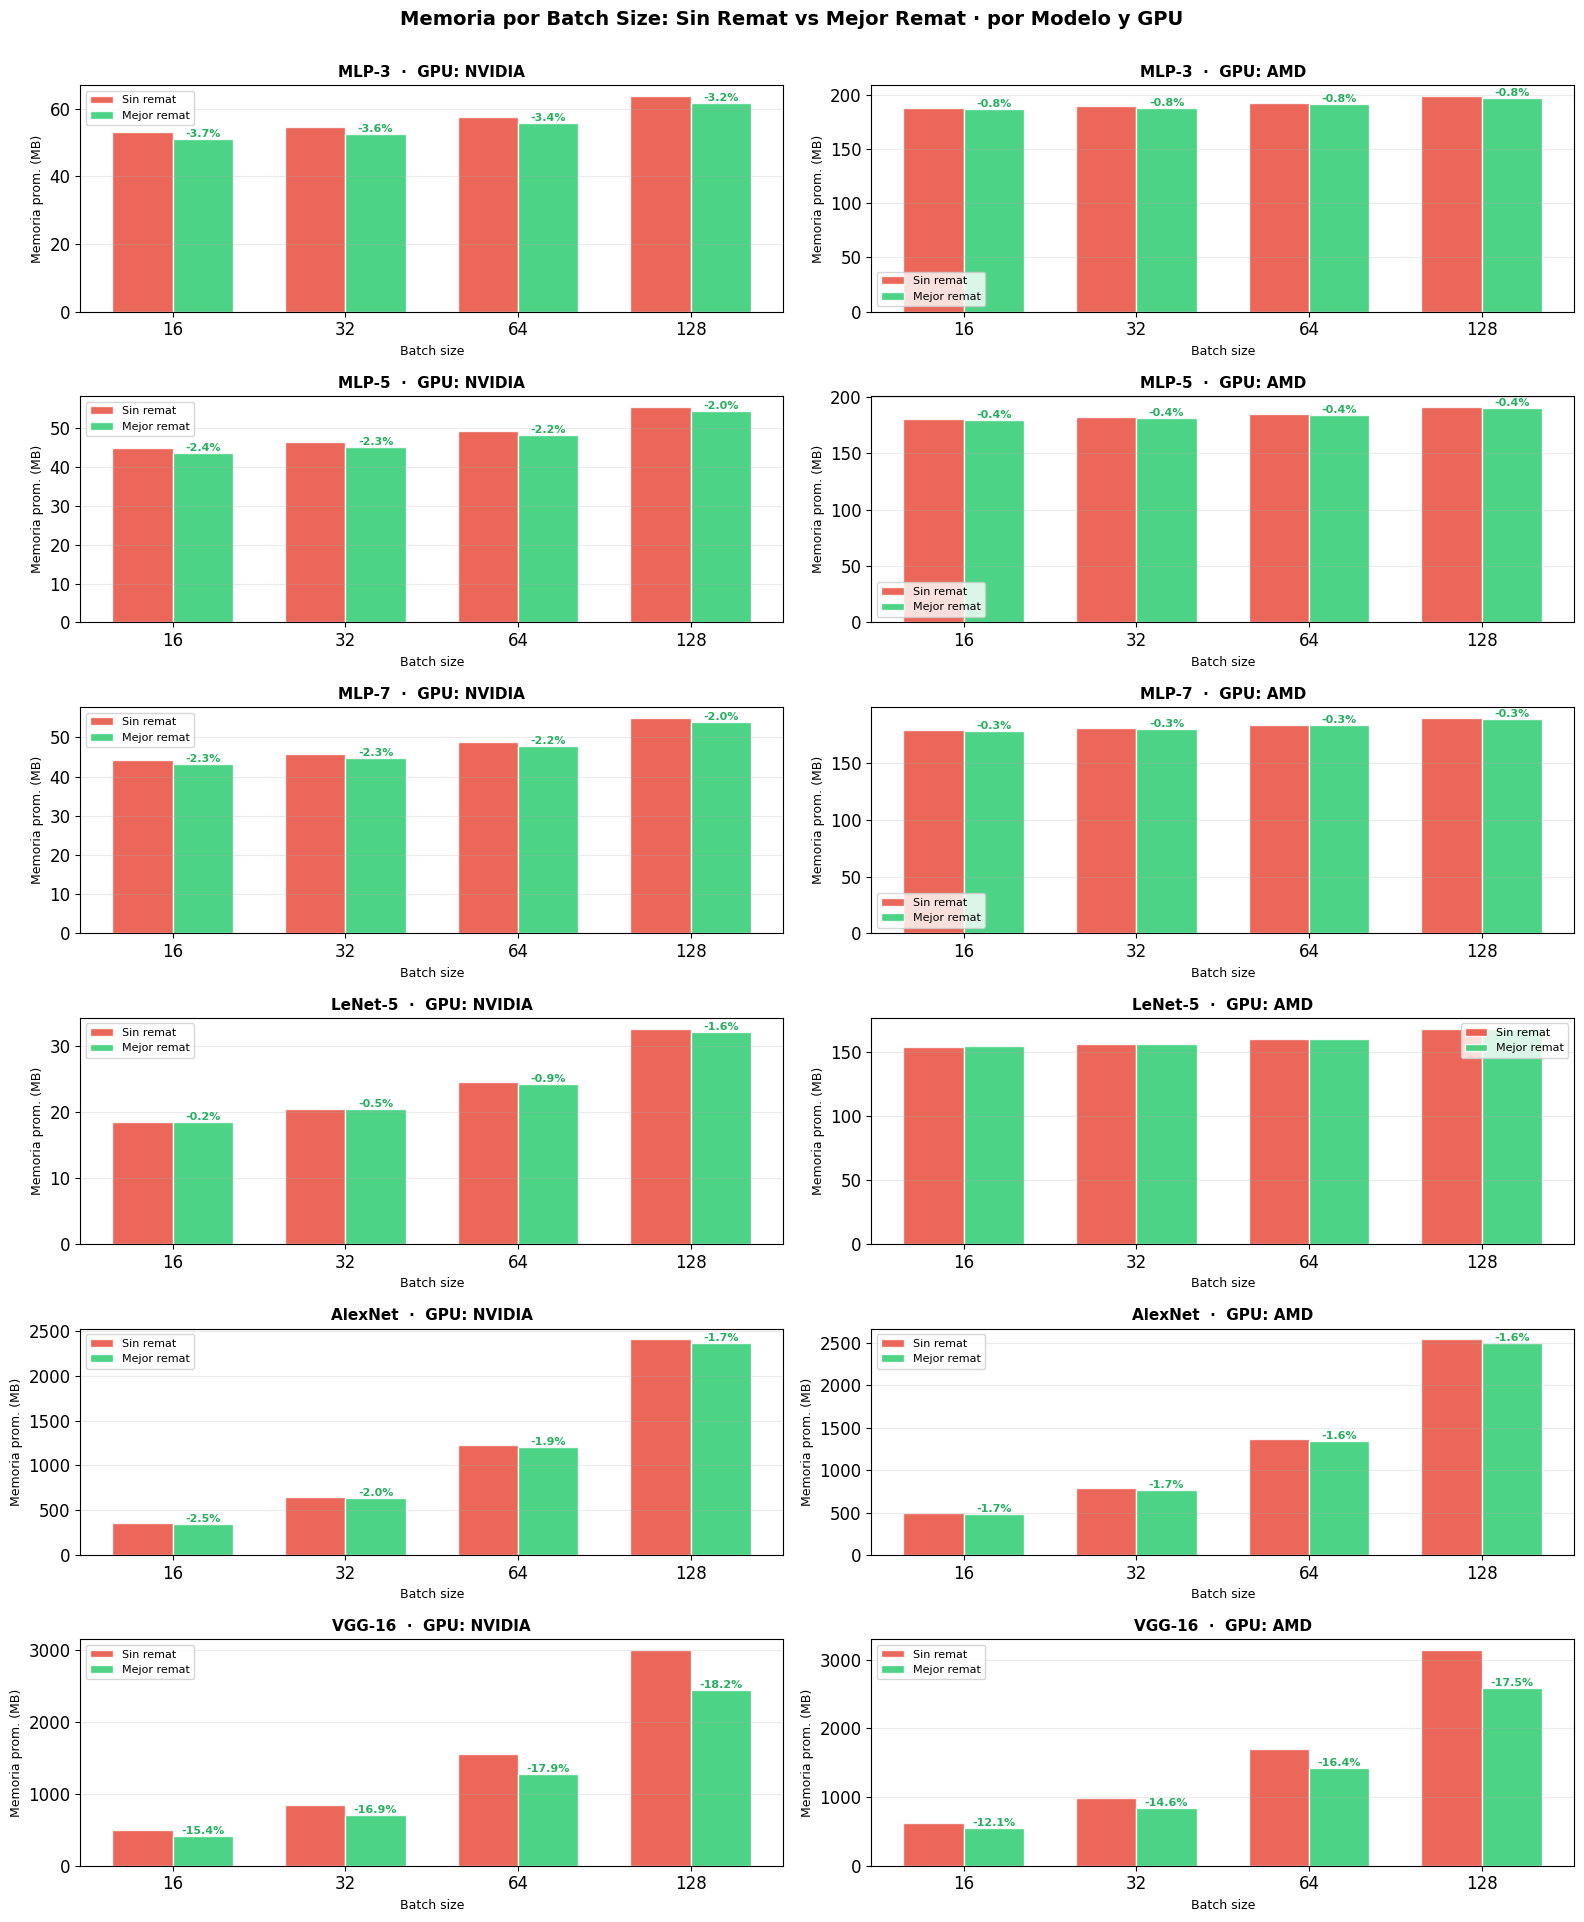

In [27]:
# Visualización: barras de memoria por batch, todos los modelos, separado por GPU
all_models = ['MLP-3', 'MLP-5', 'MLP-7', 'LeNet-5', 'AlexNet', 'VGG-16']
gpus = ['NVIDIA', 'AMD']

fig, axes = plt.subplots(len(all_models), len(gpus),
                         figsize=(16, 3.2 * len(all_models)), squeeze=False)

for i, modelo_name in enumerate(all_models):
    for j, gpu_name in enumerate(gpus):
        ax = axes[i, j]
        mod_df = df_analysis[(df_analysis['modelo'] == modelo_name) &
                              (df_analysis['gpu'] == gpu_name)]
        if len(mod_df) == 0:
            ax.set_visible(False)
            continue

        batch_sizes = sorted(mod_df['batch_size'].unique())
        x = np.arange(len(batch_sizes))
        width = 0.35

        # Promedio sin remat por batch
        mem_no, mem_remat = [], []
        for bs in batch_sizes:
            no_r = mod_df[(mod_df['batch_size'] == bs) &
                          (~mod_df['tiene_remat'])]['memory_avg_MB']
            remat_r = mod_df[(mod_df['batch_size'] == bs) &
                              (mod_df['tiene_remat'])]['memory_avg_MB']
            mem_no.append(no_r.mean() if len(no_r) > 0 else np.nan)
            mem_remat.append(remat_r.min() if len(remat_r) > 0 else
                             (no_r.mean() if len(no_r) > 0 else np.nan))

        bars1 = ax.bar(x - width/2, mem_no, width, label='Sin remat',
                       color='#e74c3c', alpha=0.85, edgecolor='white')
        bars2 = ax.bar(x + width/2, mem_remat, width, label='Mejor remat',
                       color='#2ecc71', alpha=0.85, edgecolor='white')

        for k, (no_r, best_r) in enumerate(zip(mem_no, mem_remat)):
            if np.isnan(no_r) or np.isnan(best_r) or no_r == 0:
                continue
            ahorro = (no_r - best_r) / no_r * 100
            if ahorro > 0.05:
                ax.annotate(f'-{ahorro:.1f}%',
                            xy=(k + width/2, best_r),
                            ha='center', va='bottom', fontsize=8, fontweight='bold',
                            color='#27ae60')

        ax.set_xlabel('Batch size', fontsize=9)
        ax.set_ylabel('Memoria prom. (MB)', fontsize=9)
        ax.set_title(f'{modelo_name}  ·  GPU: {gpu_name}',
                     fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(batch_sizes)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25, axis='y')

plt.suptitle('Memoria por Batch Size: Sin Remat vs Mejor Remat · por Modelo y GPU',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


**Observación sobre LeNet-5 + GPU AMD (barras sin rematerialización visible):**

En el subplot correspondiente a **LeNet-5 en la GPU AMD (Instinct MI210)**, la barra verde (*Mejor remat*) prácticamente coincide con la barra roja (*Sin remat*) y, visualmente, no se aprecia un ahorro separado. La explicación más probable es una combinación de los siguientes factores:

1. **Tamaño absoluto de las activaciones es muy pequeño.** LeNet-5 es la arquitectura más liviana del conjunto (2 capas convolucionales con pocos filtros, mapas de activación de dimensión modesta). El presupuesto total de memoria de activaciones sobre el que la rematerialización puede actuar es muy reducido, así que el ahorro absoluto en MB cae dentro del ruido de medición.
2. **VRAM abundante en AMD MI210 (64 GB).** Con ese tamaño de VRAM, el asignador de memoria no está bajo presión para LeNet-5 con ningún batch del experimento. No hay “picos” que aliviar; el sistema no tiene incentivo para liberar agresivamente ni para mover tensores.
3. **Overhead de la propia mecánica de checkpoint.** `torch.utils.checkpoint` introduce un costo fijo por cada segmento recomputado (grafo auxiliar, save/restore de tensores). En redes muy pequeñas este costo fijo puede **compensar o incluso superar** el ahorro, dejando el `memory_avg_MB` prácticamente igual al baseline.
4. **Granularidad del profiling.** `memory_avg_MB` se computa como promedio sobre iteraciones. Pequeñas variaciones quedan absorbidas por el promedio, y si el ahorro instantáneo es del orden de decenas de MB frente a un consumo base de varios cientos, la barra verde no se distingue a simple vista de la roja en la misma escala.

En resumen, la ausencia de una barra verde claramente separada para LeNet-5 + AMD **no es un fallo de la rematerialización**, sino la consecuencia natural de aplicar una técnica de ahorro de memoria a un modelo que ya es barato en memoria, ejecutado sobre una GPU con memoria de sobra. Es uno de los casos donde los lineamientos de la Sección 11.6 recomiendan *no* activar la rematerialización.


### 9.4 Lineamientos Prácticos

Esta sección sintetiza los lineamientos prácticos que surgen de los escenarios anteriores, con el objetivo de **orientar el uso de la rematerialización en escenarios de recursos limitados**. Estos lineamientos identifican los casos en los que la técnica resulta más eficiente y aquellos en los que es preferible entrenar sin ella, aportando un marco de aplicación práctica que complementa el modelo predictivo y su validación experimental.

El análisis se enfoca en evaluar el **impacto del tamaño de lote y la topología de red** sobre el consumo de memoria y el tiempo de cómputo, que son las dos dimensiones del trade-off modelado en este notebook.

#### Lineamientos según la topología de red

| Topología | Comportamiento observado | Lineamiento |
|---|---|---|
| **MLP (3, 5, 7 capas)** | Eficiencia (ahorro mem % / Δtotal_time_ms %) por debajo de 0.1 en casi todas las configuraciones. Activaciones fully-connected pequeñas → ahorro despreciable. | **No aplicar rematerialización.** El costo de recomputación supera al ahorro de memoria. |
| **LeNet-5** | Ahorro real modesto; eficiencia cercana al umbral. En GPU con VRAM abundante (MI210) la mejora es casi imperceptible. | **Activar solo bajo presión de memoria real.** En GPUs holgadas, no se justifica. |
| **AlexNet** | Eficiencia claramente por encima de 0.1. Checkpoint selectivo sobre capas convolucionales da la mejor relación ahorro/overhead. | **Usar checkpoint selectivo** en capas convolucionales; evitar las variantes totales que no aportan beneficio adicional. |
| **VGG-16** | Mediana de eficiencia más alta del conjunto, con ahorros de memoria relevantes en términos absolutos. | **Usar rematerialización.** Uniform segment para máximo ahorro; selectivo (p.ej. primeros bloques) para balance. |

#### Lineamientos según el tamaño de lote

| Batch | Observación | Lineamiento |
|---|---|---|
| **16** | Consumo total bajo; el margen absoluto para ahorrar es pequeño. | Rematerialización útil **solo en VGG-16** si la GPU está casi llena. |
| **32 – 64** | Zona donde la relación ahorro/Δtime es más favorable en CNN medianas y grandes. | Activar **checkpoint selectivo** en AlexNet y VGG-16. |
| **128** | Consumo alto; la rematerialización libera más MB en absoluto, pero duplicar el batch aún con remat no suele caber. | Útil para **VGG-16**; permite mantenerse dentro de la VRAM, pero no habilita saltos grandes de batch. |

#### Lineamientos según la GPU

| GPU | VRAM | Lineamiento |
|---|---|---|
| **NVIDIA GTX Titan X** | 12 GB | Presión de memoria real en CNN medianas/grandes con batch altos. La rematerialización es relevante sobre todo para VGG-16 y AlexNet con batch ≥ 64. |
| **AMD Instinct MI210** | 64 GB | Memoria abundante. La rematerialización rara vez es necesaria salvo en cargas concurrentes o modelos extremadamente grandes. |

#### Criterio de decisión operacional (usando el Random Forest entrenado)

1. Predecir `memory_avg_MB` y `total_time_ms` del *baseline* sin rematerialización para el `(modelo, GPU, batch, activación)` de interés.
2. Predecir lo mismo para todas las configuraciones candidatas con rematerialización.
3. Calcular `ahorro_mem_pct` y `Δtotal_time_ms_pct` sobre esas predicciones y la eficiencia asociada.
4. **Activar rematerialización solo si** la eficiencia ≥ 0.1 **o** existe una restricción dura de memoria que, sin remat, impediría entrenar.

#### Cuándo **NO** aplicar rematerialización

- MLPs de cualquier profundidad.
- LeNet-5 en GPU con VRAM amplia (caso AMD MI210): el ahorro absoluto es insignificante y el overhead no compensa.
- Cualquier configuración con eficiencia predicha < 0.1.

#### Cuándo **SÍ** aplicar rematerialización

- VGG-16 (y arquitecturas profundas equivalentes) en GPUs con VRAM apretada (Titan X).
- Cuando el entrenamiento está en el borde de OOM y un checkpoint selectivo pequeño libera el margen necesario para completar la iteración.
- Cuando la prioridad es sostener el batch máximo para mejorar convergencia y se acepta pagar el costo en `total_time_ms`.

Estos lineamientos operan como una **capa de decisión** sobre el modelo predictivo: el Random Forest estima la memoria y el tiempo esperados para una configuración dada, y los criterios anteriores los traducen en una recomendación práctica (aplicar / no aplicar / qué variante usar). El resultado es un marco aplicable que complementa la validación experimental con una guía inmediata para el practicante que entrena redes en GPUs limitadas.
